# 02 — Parameter Sweeps (Batching)

This notebook demonstrates batched evaluation of the same integral over a grid of parameter values.

Example: Fourier transform of a Gaussian
$$
I(k) = \int_{-\infty}^{\infty} e^{-x^2} e^{i k x}dx = \sqrt{i}e^{-k^2/4}.
$$
We compute $I(k)$ for many $k$ values at once.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import torch
import sympy as sp

ROOT = Path.cwd().parents[1]
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import symtorch

device = torch.device('cpu')
dtype = torch.float64

In [5]:
# Build the integral once
x = sp.Symbol('x', real=True)
k = sp.Symbol('k', real=True)
integrand = sp.exp(-x**2) * sp.exp(sp.I * k * x)
integral = sp.Integral(integrand, (x, -sp.oo, sp.oo))
integral

Integral(exp(-x**2)*exp(I*k*x), (x, -oo, oo))

In [6]:

lt = symtorch.SymTorch()
texpr = lt.torchify(integral)
print('dim:', texpr.dim, 'n_params:', texpr.n_params, 'domain:', texpr.domain)

dim: 1 n_params: 1 domain: [[-1.5707962267948965, 1.5707962267948965]]


In [3]:
# Sweep k values in one call
k_grid = torch.linspace(-5.0, 5.0, 201, device=device, dtype=dtype).unsqueeze(-1)  # (201, 1)
re, im = texpr.torch_integrate_batched(
    params_values=k_grid,
    method='gauss-legendre',
    N=80,
    device=device,
    dtype=dtype,
    chunk_size_params=64,
)

expected = torch.sqrt(torch.tensor(torch.pi, device=device, dtype=dtype)) * torch.exp(-(k_grid.squeeze(-1) ** 2) / 4.0)

max_abs_err = (re - expected).abs().max().item()
print('max |re-expected|:', max_abs_err)
print('max |im|        :', im.abs().max().item())

max |re-expected|: 3.987396454685488e-10
max |im|        : 1.6952813867879106e-16


Saved: c:\Users\Pc\Desktop\LOCALS\F_Nutku_Studies\LibTorch\examples\plots\02_parameter_sweeps.png


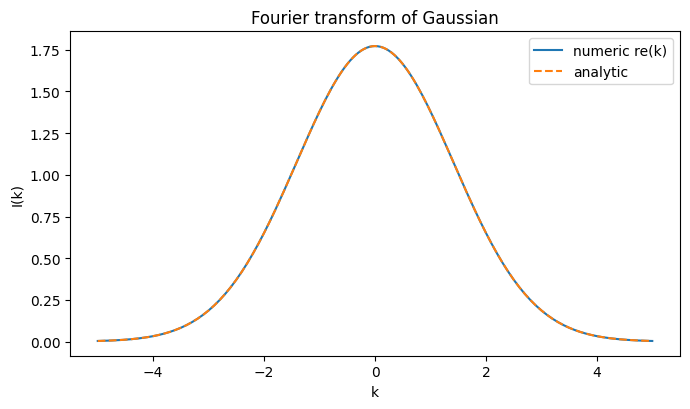

In [ ]:
# Plot and save under examples/plots/
import matplotlib.pyplot as plt

k_cpu = k_grid.squeeze(-1).cpu().numpy()
re_cpu = re.cpu().numpy()
ex_cpu = expected.cpu().numpy()

plt.figure(figsize=(7, 4.2))
plt.plot(k_cpu, re_cpu, label='numeric re(k) [SymTorch]')
plt.plot(k_cpu, ex_cpu, '--', label='analytic (reference)')
plt.title('Fourier transform of Gaussian (computed via SymTorch)')
plt.xlabel('k')
plt.ylabel('I(k)')
plt.legend()
plt.tight_layout()

out_path = ROOT / 'examples' / 'plots' / '02_parameter_sweeps.png'
plt.savefig(out_path, dpi=150)
print('Saved:', out_path)
